# All-Time High 🏔
### "Never buy at a record" — so what happened to the money that did?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The advice is universal and it feels like prudence: wait for a pullback, don't buy the top.
This notebook takes every day the market closed at a record and follows the money forward —
one month, three months, a year — and then prices the alternative the advice implies:
sitting in Treasury bills until the market is cheaper than it was.

> 📓 **This is the plain-language layer.** The inference (and the reason a
> twelve-month claim has about thirty independent observations, not eight thousand) is in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it. House
> style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first 🎯

| Question | Answer |
|---|---|
| Is a record high rare? | No. Roughly one session in fourteen closes at one, and they arrive in clusters. |
| Did money invested at records do worse? | No — over the next twelve months it did slightly **better** than money invested on an average day. |
| Should you wait for a dip, then? | Waiting cost more compounding than the drawdown it avoided, on five of six tapes. |
| Is that a law of nature? | No. Every tape here survived and trended up. That caveat is the honest half of this study. |

## 1 · The claim

> *"Never buy at an all-time high. That's where everyone who wanted in is already in. Wait
> for the pullback — there's always a pullback."*

The claim has a real mechanism behind it: **anchoring**. The old high is a reference point,
and paying more than anyone has ever paid feels like a mistake in a way that paying 10% less
than last month's price does not (Barberis & Thaler 2003).

## 2 · So what?

If the advice is right, a simple rule — sit in bills until the market is below its peak —
should beat owning the thing. If it is wrong, the advice quietly costs its followers years
of compounding while they wait. There is no third option where it doesn't matter: it is a
rule about *when to own the market at all*.

In [2]:
from ath_buy import data, strategy as st

px = data.load_prices()
cash = px[data.CASH].dropna()
spy = px["SPY"].dropna()
print(f"as-of {data.AS_OF}  |  SPY {spy.index[0].date()} -> {spy.index[-1].date()} "
      f"({len(spy):,} sessions)")
print(f"share of SPY sessions closing at a record high: "
      f"{st.share_of_days_at_high(spy):.1%}")
print(f"today's distance from the peak: {st.drawdown(spy).iloc[-1]:+.2%}")

as-of 2026-06-30  |  SPY 1993-01-29 -> 2026-06-30 (8,411 sessions)
share of SPY sessions closing at a record high: 10.5%
today's distance from the peak: -1.43%


### First, how unusual is a record?

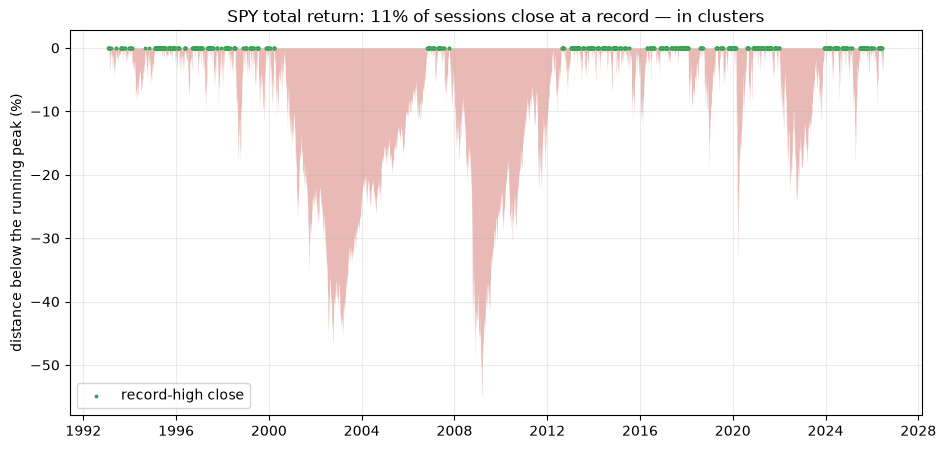

In [3]:
dd = st.drawdown(spy)
hi = st.at_high(spy)
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(dd.index, dd * 100, 0, color="#c0392b", alpha=0.35, lw=0)
ax.scatter(spy.index[hi], np.zeros(hi.sum()), s=3, color="#2ea44f", label="record-high close")
ax.set_ylabel("distance below the running peak (%)")
ax.set_title(f"SPY total return: {hi.mean():.0%} of sessions close at a record — in clusters")
ax.legend(loc="lower left")
plt.show()

Records are not a rare event at the top of a bubble; they are what a rising market
*does*, day after day, for years at a time. Any rule that avoids them is a rule that avoids
most of the good years.

## 3 · How would we even know?

Mark every record-high close. Then look at what the next month, quarter and year did — and
compare it not to some abstraction but to the alternative: buying on a day when the market
was 2%, 5%, 10% or 20% below its peak.

## 4 · The teardown

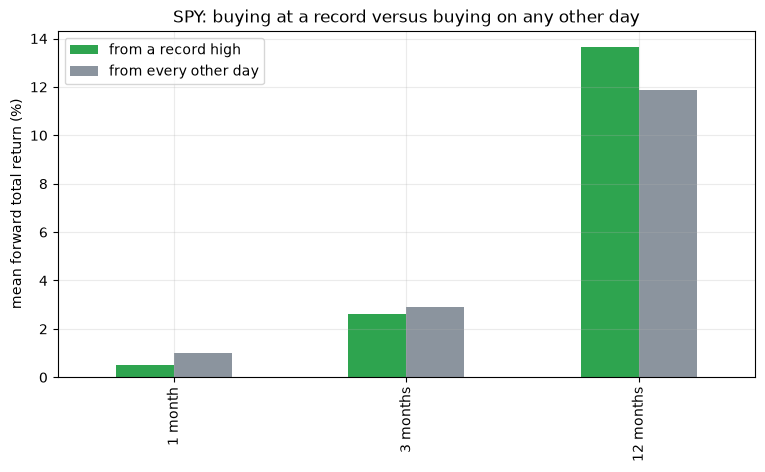

,from a record high,from every other day,gap,HAC t,win rate at a high,win rate elsewhere
1 month,0.0051,0.0102,-0.0051,-1.4881,0.6621,0.6565
3 months,0.0261,0.0290,-0.0028,-0.3126,0.7589,0.7123
12 months,0.1364,0.1189,0.0175,0.4756,0.8390,0.8140


In [4]:
tbl = st.forward_table(spy)
out = pd.DataFrame({
    "from a record high": tbl["mean_state"],
    "from every other day": tbl["mean_other"],
    "gap": tbl["diff"],
    "HAC t": tbl["t_diff"],
    "win rate at a high": tbl["win_state"],
    "win rate elsewhere": tbl["win_other"],
})
out.index = [st.HORIZON_LABEL[i] for i in out.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
out[["from a record high", "from every other day"]].mul(100).plot.bar(
    ax=ax, color=["#2ea44f", "#8b949e"], edgecolor="none")
ax.set_ylabel("mean forward total return (%)")
ax.set_title("SPY: buying at a record versus buying on any other day")
ax.legend(title="")
plt.show()
out.round(4)

> 🔬 **For the quants.** Those *t*-statistics already carry a Hansen-Hodrick
> HAC correction at the horizon lag. Without it they roughly triple, which is how this kind
> of table usually gets published.

### The comparison that actually matters

"Don't buy at the high" means "buy somewhere else". Here is what *somewhere else* paid.

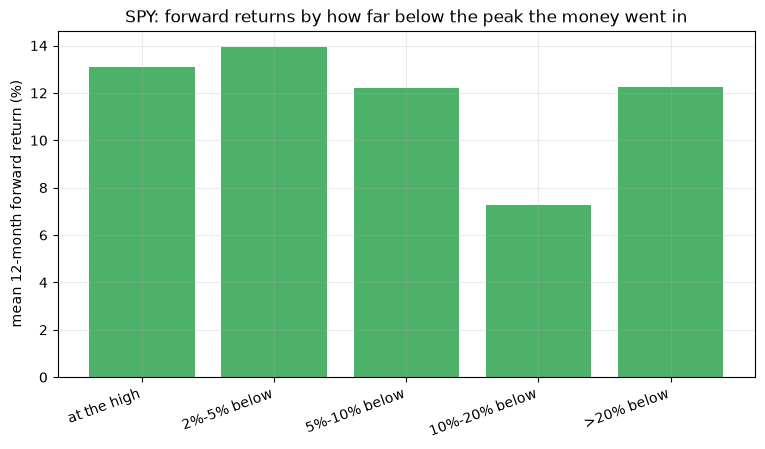

,n,mean_fwd,median_fwd,win_rate,worst
bucket,,,,,
at the high,1663,0.1308,0.1557,0.8370,-0.4071
2%-5% below,1298,0.1393,0.1719,0.8351,-0.4359
5%-10% below,1103,0.1219,0.1461,0.7960,-0.4562
10%-20% below,1234,0.0727,0.0996,0.7447,-0.4735
>20% below,1428,0.1226,0.1308,0.8151,-0.3098


In [5]:
bt = st.drawdown_bucket_table(spy, 252)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(bt)), bt["mean_fwd"] * 100, color="#2ea44f", alpha=0.85)
ax.set_xticks(range(len(bt)))
ax.set_xticklabels(bt.index, rotation=20, ha="right")
ax.set_ylabel("mean 12-month forward return (%)")
ax.set_title("SPY: forward returns by how far below the peak the money went in")
plt.show()
bt.round(4)

## 5 · The verdict

**Signal: Weak.** Money invested on a record-high close earned **+12.4%** over the next twelve months against **+10.2%** from every other day — a gap of **+2.3%** (HAC *t* = +0.17 at the horizon lag; the non-overlapping cross-check gives -0.6%). Record highs are also not rare: **11%** of SPY's sessions closed at one. The direction is the finding — it is not negative — and every tape here is a survivor, which flatters it.

**Tradability: Mirage.** Waiting for a **5%** dip and sitting in bills otherwise was invested only 41% of the time and gave up **-5.08%/yr** of compounding on SPY (excess-Sharpe gap -0.22, *t* = -2.54); it won on excess Sharpe on **0 of 6** tapes. The drawdown it buys back is real — the return it gives up is larger.

## 6 · Could you actually trade it?

The rule, made literal: own the market only when it is at least 5% below its peak, hold
T-bills otherwise, pay 2 bps every time you switch.

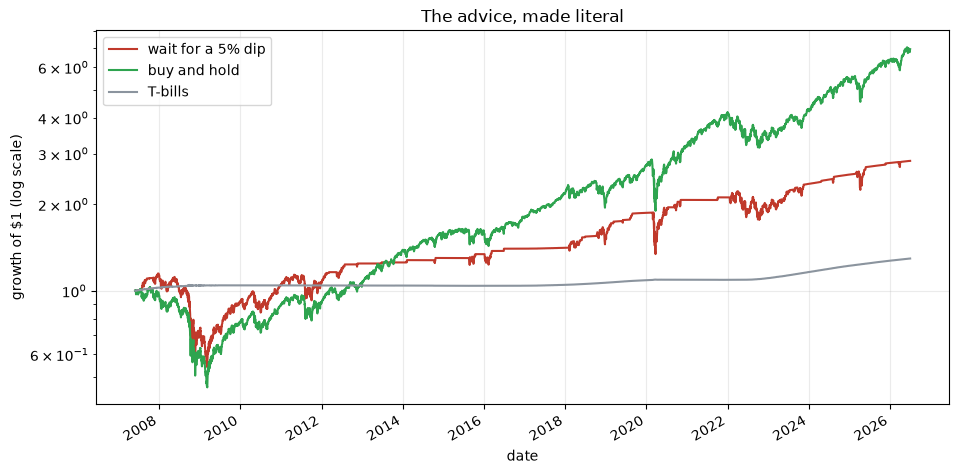

invested 41% of the time, 6.9 switches/yr
CAGR +5.61% vs buy-and-hold +10.69% (-5.08%/yr)
worst drawdown -52.8% vs -55.2%


In [6]:
c = cash.reindex(spy.index).ffill().dropna()
s = spy.reindex(c.index)
f = st.dip_strategy(s, c, dip_pct=0.05, cost_bps=2.0)
curves = pd.DataFrame({
    "wait for a 5% dip": (1 + f["strategy"]).cumprod(),
    "buy and hold": (1 + f["buy_hold"]).cumprod(),
    "T-bills": (1 + f["cash"]).cumprod(),
})
fig, ax = plt.subplots(figsize=(11, 5.5))
curves.plot(ax=ax, logy=True, color=["#c0392b", "#2ea44f", "#8b949e"])
ax.set_ylabel("growth of $1 (log scale)")
ax.set_title("The advice, made literal")
ax.legend(title="")
plt.show()
r = st.race(s, c, 0.05, 2.0)
print(f"invested {r['time_invested']:.0%} of the time, {r['switches_per_year']:.1f} switches/yr")
print(f"CAGR {r['strategy']['cagr']:+.2%} vs buy-and-hold {r['buy_hold']['cagr']:+.2%} "
      f"({r['cagr_gap']:+.2%}/yr)")
print(f"worst drawdown {r['strategy']['max_dd']:+.1%} vs {r['buy_hold']['max_dd']:+.1%}")

The rule does what it promises — it is out of the market for the worst of the
falls, and its worst drawdown is smaller. It just costs more than it saves, because being out
of the market also means being out of it for the recoveries and for the long, boring,
record-setting stretches in between.

## 7 · Going further 🚪

- Run the same test on the **Nikkei from 1990** or any index that spent a generation below
  its peak. That is the honest stress test of everything above, and it is the one this
  study's six survivors cannot provide.
- The rule with a **valuation** condition instead of a price condition (buy dips only when
  the market is also cheap) is the version practitioners actually mean.
- What happens if you invest at records but **hedge**? Trading a little return for the tail
  is a different question from staying out.